# Detección de Escala Espacial con el Semivariograma
### *Ejemplo Rápido — Ecología de Paisajes*

---

Este notebook demuestra cómo:

1. Generar un **paisaje sintético** con escala de autocorrelación espacial conocida (σ)
2. **Muestrear** puntos aleatorios sobre ese paisaje
3. **Calcular el semivariograma empírico** a múltiples distancias de rezago
4. **Ajustar un modelo teórico** (gaussiano) al semivariograma
5. **Recuperar los parámetros estructurales** — meseta, pepita y rango

> **Relación con el notebook anterior:** La *I* de Moran mide *similitud* entre vecinos; el semivariograma mide *disimilitud*. Ambos revelan la misma estructura espacial, pero desde ángulos opuestos. Son herramientas complementarias: el correlograma es más intuitivo; el semivariograma es el estándar en geoestadística y es esencial para el *kriging* (interpolación espacial).

## 0 · Instalación de dependencias

In [1]:
!pip install numpy scipy matplotlib scikit-learn --quiet

## 1 · Importaciones

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2 · Generar el paisaje sintético

Usamos exactamente el mismo procedimiento que en el cuaderno de Moran's I:  
ruido blanco + filtro gaussiano con σ conocido.  
Esto nos permite comparar directamente ambos métodos sobre los mismos datos.

| Parámetro | Significado |
|-----------|-------------|
| `n` | Tamaño de la grilla (n × n celdas) |
| `SIGMA` | Escala característica verdadera — lo que queremos recuperar |

In [3]:
np.random.seed(42)
n     = 100
SIGMA = 15  # celdas — la "verdad" que queremos recuperar

white_noise = np.random.randn(n, n)
landscape   = gaussian_filter(white_noise, sigma=SIGMA)

print(f"Escala característica verdadera σ = {SIGMA} celdas")

Escala característica verdadera σ = 15 celdas


## 3 · Muestrear puntos aleatorios

Extraemos `n_samples` ubicaciones al azar y registramos el valor del paisaje en cada una.  
A partir de aquí, trabajamos **solo con estos puntos** — como en un estudio de campo real.

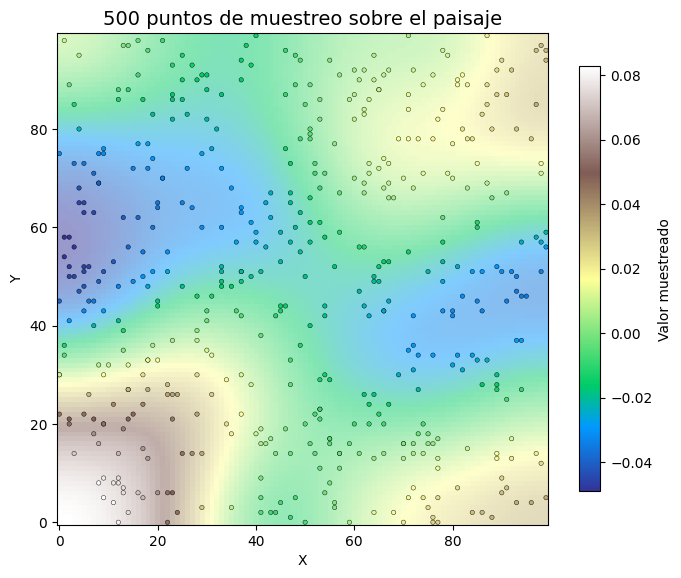

✓ 500 puntos muestreados.


In [4]:
n_samples = 500
xs     = np.random.randint(0, n, n_samples)
ys     = np.random.randint(0, n, n_samples)
values = np.array([landscape[x, y] for x, y in zip(xs, ys)])
coords = np.column_stack([xs, ys])

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(landscape, cmap='terrain', origin='lower', alpha=0.5)
scatter = ax.scatter(ys, xs, c=values, cmap='terrain', s=10,
                     edgecolors='black', linewidths=0.3)
ax.set_title(f'{n_samples} puntos de muestreo sobre el paisaje', fontsize=14)
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.colorbar(scatter, ax=ax, shrink=0.8, label='Valor muestreado')
plt.tight_layout()
plt.savefig('01_muestras_semivariograma.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ {n_samples} puntos muestreados.")

## 4 · ¿Qué es la semivarianza?

### Definición

Para dos puntos separados por una distancia $h$ (el $\Delta$d, o *rezago*), la semivarianza $\gamma(h)$ mide  
**cuánto difieren sus valores en promedio**:

$$\gamma(h) = \frac{1}{2 \, N(h)} \sum_{i=1}^{N(h)} \left[ z(\mathbf{x}_i) - z(\mathbf{x}_i + h) \right]^2$$

| Símbolo | Significado |
|---------|-------------|
| $h$ | $\Delta$d, distancia de rezago |
| $N(h)$ | número de pares de puntos separados por $h$ |
| $z(\mathbf{x}_i)$ | valor en la ubicación $\mathbf{x}_i$ |

### ¿Cómo se interpreta?

- A **$\Delta$d cortos**: los puntos son similares → la diferencia es pequeña → $\gamma$ es baja  
- A **$\Delta$d largos**: los puntos ya no se parecen → $\gamma$ aumenta  
- A partir de cierta distancia, $\gamma$ se estabiliza: **ya no hay autocorrelación**

### Los tres parámetros del semivariograma

```
       Meseta (sill) ─────────────────────────────────
                    ╱
                   ╱
                  ╱
   Pepita (nugget)╱___________
                  |           |
                  0         Rango (range)        h →
```


![alt="Semivariograma (Wikipedia)"](https://github.com/horaciosamaniego/cbit241/blob/main/500px-Schematic_variogram.svg.png?raw=true)


| Parámetro | Símbolo | Significado ecológico |
|-----------|---------|----------------------|
| **Pepita** (nugget) | $C_0$ | Variación a escala < grano de muestreo + error de medición |
| **Meseta** (sill) | $C_0 + C$ | Varianza total — $\gamma$ deja de crecer |
| **Rango** (range) | $a$ | Distancia a la que se alcanza la meseta → **escala característica** |

> El **rango** es el equivalente al cruce por cero en el correlograma de Moran's *I*:  
> ambos marcan el límite de la dependencia espacial.

## 5 · Calcular el semivariograma empírico

Usamos bandas anulares `[d−2, d]` — la misma estrategia que con Moran's *I* —  
para aislar la contribución de cada distancia.

In [5]:
# Precalcular todas las distancias por pares
dists_all = cdist(coords, coords)

lag_centers  = np.arange(3, 60, 2)
gamma_values = []
pair_counts  = []

print("Calculando semivariograma empírico...")
print(f"{'Rezago (celdas)':>16} {'γ(h)':>12} {'N pares':>10}")
print("-" * 40)

for d in lag_centers:
    # Banda anular: pares entre d-2 y d
    mask = (dists_all <= d) & (dists_all > d - 2)
    # Solo triangulo superior para no contar pares dos veces
    mask = np.triu(mask, k=1)
    idx_i, idx_j = np.where(mask)
    n_pairs = len(idx_i)

    if n_pairs < 10:
        gamma_values.append(np.nan)
        pair_counts.append(n_pairs)
        continue

    diffs = values[idx_i] - values[idx_j]
    gamma = np.sum(diffs**2) / (2 * n_pairs)

    gamma_values.append(gamma)
    pair_counts.append(n_pairs)
    print(f"{d:>16.0f} {gamma:>12.4f} {n_pairs:>10}")

gamma_values = np.array(gamma_values)
print("\n✓ Semivariograma empírico calculado.")

Calculando semivariograma empírico...
 Rezago (celdas)         γ(h)    N pares
----------------------------------------
               3       0.0000        332
               5       0.0000        632
               7       0.0000        812
               9       0.0000       1186
              11       0.0001       1258
              13       0.0001       1613
              15       0.0001       1868
              17       0.0002       1924
              19       0.0002       2278
              21       0.0003       2248
              23       0.0004       2574
              25       0.0004       2643
              27       0.0005       2725
              29       0.0005       2759
              31       0.0006       2964
              33       0.0007       3126
              35       0.0006       3323
              37       0.0007       3283
              39       0.0007       3382
              41       0.0007       3212
              43       0.0008       3403
              45   

## 6 · Modelos teóricos de semivariograma

El semivariograma empírico es ruidoso. En geoestadística se ajusta un **modelo teórico**  
que garantiza propiedades matemáticas necesarias para la interpolación (kriging).

Los tres modelos más comunes son:

| Modelo | Fórmula | Característica |
|--------|---------|---------------|
| **Esférico** | lineal al inicio, corte abrupto en $a$ | El más usado en suelos y ecología |
| **Exponencial** | sube continuamente, nunca corta exactamente | Procesos con correlación decreciente suave |
| **Gaussiano** | curva en S, muy suave al origen | Fenómenos muy continuos — como el nuestro |

Dado que nuestro paisaje fue generado con un filtro gaussiano, el modelo gaussiano  
debería ajustar mejor.

In [6]:
# ── Definición de los tres modelos ────────────────────────────────────────────

def modelo_esferico(h, nugget, sill, rango):
    """Semivariograma esférico."""
    gamma = np.where(
        h <= rango,
        nugget + (sill - nugget) * (1.5 * h/rango - 0.5 * (h/rango)**3),
        sill
    )
    return np.where(h == 0, 0, gamma)

def modelo_exponencial(h, nugget, sill, rango):
    """Semivariograma exponencial."""
    gamma = nugget + (sill - nugget) * (1 - np.exp(-h / rango))
    return np.where(h == 0, 0, gamma)

def modelo_gaussiano(h, nugget, sill, rango):
    """Semivariograma gaussiano."""
    gamma = nugget + (sill - nugget) * (1 - np.exp(-(h / rango)**2))
    return np.where(h == 0, 0, gamma)

print("✓ Modelos teóricos definidos.")

✓ Modelos teóricos definidos.


## 7 · Ajustar los modelos al semivariograma empírico

Usamos `scipy.optimize.curve_fit` para encontrar los parámetros  
(pepita, meseta, rango) que mejor se ajustan a los datos empíricos.

In [7]:
# Filtrar NaN para el ajuste
mask_valid = ~np.isnan(gamma_values)
h_fit      = lag_centers[mask_valid]
g_fit      = gamma_values[mask_valid]

# Valores iniciales y límites
sill_est   = np.var(values)
nugget_est = 0.0
rango_est  = 20.0

p0     = [nugget_est, sill_est, rango_est]
bounds = ([0, 0, 1], [sill_est, sill_est * 2, 80])

resultados = {}
for nombre, modelo in [("Esférico",     modelo_esferico),
                        ("Exponencial",  modelo_exponencial),
                        ("Gaussiano",    modelo_gaussiano)]:
    try:
        popt, _ = curve_fit(modelo, h_fit, g_fit, p0=p0, bounds=bounds, maxfev=5000)
        residuos = g_fit - modelo(h_fit, *popt)
        rmse     = np.sqrt(np.mean(residuos**2))
        resultados[nombre] = {"popt": popt, "rmse": rmse}
        nugget, sill, rango = popt
        print(f"{'─'*50}")
        print(f"Modelo {nombre}:")
        print(f"  Pepita (nugget) C₀  = {nugget:.4f}")
        print(f"  Meseta (sill)   C₀+C = {sill:.4f}")
        print(f"  Rango (range)   a   = {rango:.1f} celdas")
        print(f"  RMSE                = {rmse:.5f}")
    except Exception as e:
        print(f"Modelo {nombre}: ajuste fallido ({e})")

mejor = min(resultados, key=lambda k: resultados[k]["rmse"])
print(f"\n✓ Mejor modelo: {mejor} (RMSE = {resultados[mejor]['rmse']:.5f})")

──────────────────────────────────────────────────
Modelo Esférico:
  Pepita (nugget) C₀  = 0.0000
  Meseta (sill)   C₀+C = 0.0010
  Rango (range)   a   = 79.9 celdas
  RMSE                = 0.00008
──────────────────────────────────────────────────
Modelo Exponencial:
  Pepita (nugget) C₀  = 0.0000
  Meseta (sill)   C₀+C = 0.0015
  Rango (range)   a   = 65.1 celdas
  RMSE                = 0.00009
──────────────────────────────────────────────────
Modelo Gaussiano:
  Pepita (nugget) C₀  = 0.0000
  Meseta (sill)   C₀+C = 0.0009
  Rango (range)   a   = 31.9 celdas
  RMSE                = 0.00003

✓ Mejor modelo: Gaussiano (RMSE = 0.00003)


## 8 · Visualizar el semivariograma con los modelos ajustados

El gráfico muestra el semivariograma empírico (puntos) y los tres modelos teóricos (líneas).  
Las líneas de referencia marcan la pepita, la meseta y el rango estimado.

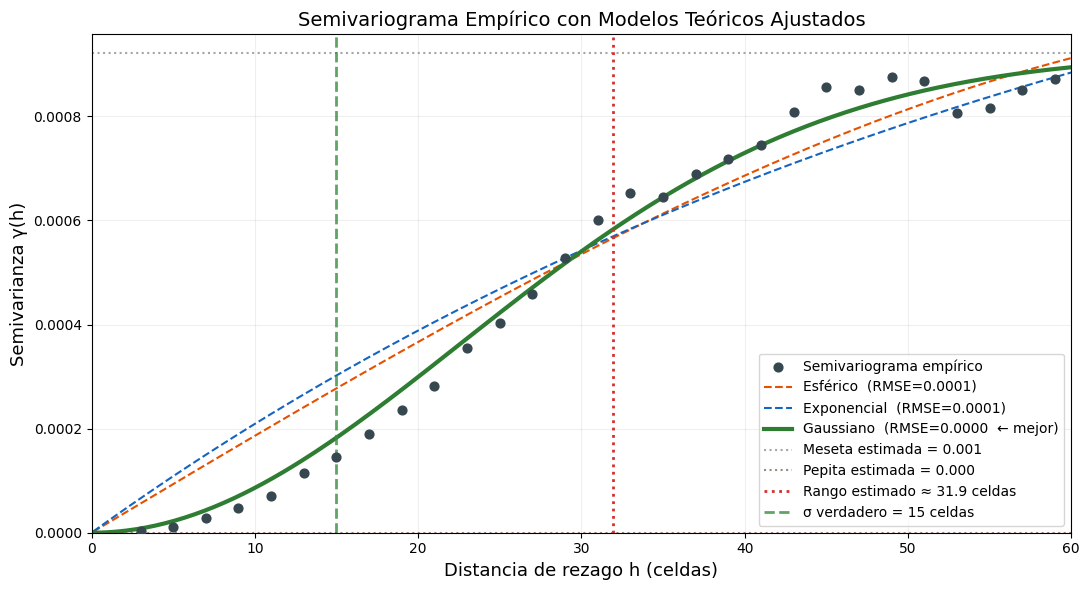

In [8]:
colores = {
    "Esférico":    "#E65100",
    "Exponencial": "#1565C0",
    "Gaussiano":   "#2E7D32"
}

h_smooth = np.linspace(0.1, 60, 300)

fig, ax = plt.subplots(figsize=(11, 6))

# Semivariograma empírico
ax.scatter(lag_centers[mask_valid], gamma_values[mask_valid],
           color='#37474F', s=40, zorder=5, label='Semivariograma empírico')

# Modelos ajustados
for nombre, modelo in [("Esférico",    modelo_esferico),
                        ("Exponencial", modelo_exponencial),
                        ("Gaussiano",   modelo_gaussiano)]:
    if nombre not in resultados:
        continue
    popt = resultados[nombre]["popt"]
    rmse = resultados[nombre]["rmse"]
    lw   = 3 if nombre == mejor else 1.5
    ls   = '-' if nombre == mejor else '--'
    ax.plot(h_smooth, modelo(h_smooth, *popt),
            color=colores[nombre], linewidth=lw, linestyle=ls,
            label=f"{nombre}  (RMSE={rmse:.4f}{'  ← mejor' if nombre == mejor else ''})")

# Parámetros del mejor modelo
nugget_m, sill_m, rango_m = resultados[mejor]["popt"]
ax.axhline(y=sill_m,   color='gray',    linestyle=':', alpha=0.7,
           label=f'Meseta estimada = {sill_m:.3f}')
ax.axhline(y=nugget_m, color='#795548', linestyle=':', alpha=0.7,
           label=f'Pepita estimada = {nugget_m:.3f}')
ax.axvline(x=rango_m,  color='#D32F2F', linestyle=':', linewidth=2,
           label=f'Rango estimado ≈ {rango_m:.1f} celdas')
ax.axvline(x=SIGMA,    color='#388E3C', linestyle='--', linewidth=2, alpha=0.8,
           label=f'σ verdadero = {SIGMA} celdas')

ax.set_xlabel('Distancia de rezago h (celdas)', fontsize=13)
ax.set_ylabel('Semivarianza γ(h)', fontsize=13)
ax.set_title('Semivariograma Empírico con Modelos Teóricos Ajustados', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('02_semivariograma_ajustado.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Comparación visual: Moran's I vs. Semivariograma

Ambas herramientas leen la misma estructura espacial desde ángulos opuestos.  
Graficamos ambas curvas juntas para ver la simetría.

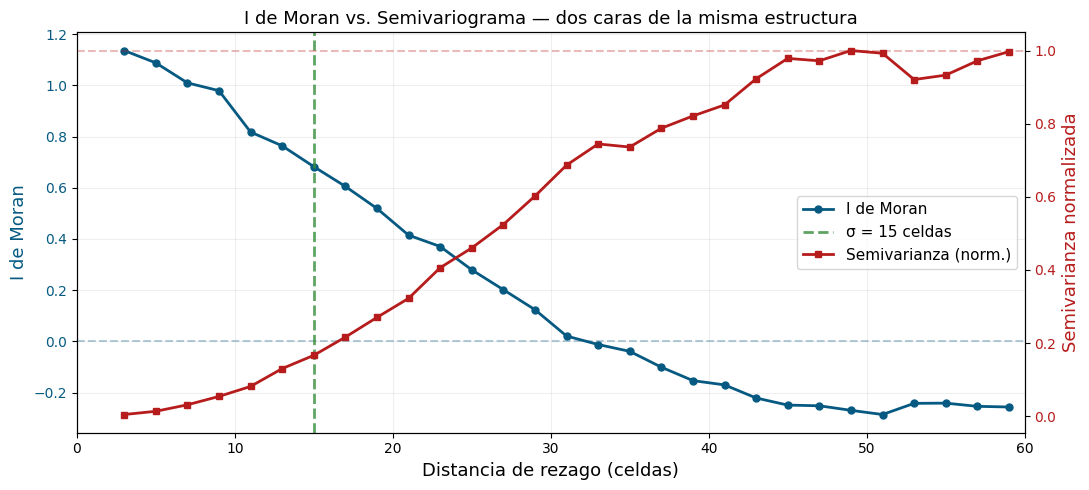

In [9]:
# Recalcular Moran's I con los mismos datos
mean_val   = np.mean(values)
deviations = values - mean_val
var_term   = np.sum(deviations**2)

morans_values = []
for d in lag_centers:
    W = (dists_all <= d) & (dists_all > d - 2) & (dists_all > 0)
    n_pairs = W.sum()
    if n_pairs < 10:
        morans_values.append(np.nan); continue
    I = len(values) * np.sum(W * np.outer(deviations, deviations)) / (n_pairs * var_term)
    morans_values.append(I)
morans_values = np.array(morans_values)

# Normalizar gamma al rango [0, 1] para poder comparar visualmente
g_norm = gamma_values / np.nanmax(gamma_values)

fig, ax1 = plt.subplots(figsize=(11, 5))

color_moran = '#065A82'
color_gamma = '#B71C1C'

ax1.plot(lag_centers, morans_values, 'o-', color=color_moran,
         markersize=5, linewidth=2, label="I de Moran")
ax1.axhline(0, color=color_moran, linestyle='--', alpha=0.3)
ax1.set_xlabel('Distancia de rezago (celdas)', fontsize=13)
ax1.set_ylabel("I de Moran", fontsize=13, color=color_moran)
ax1.tick_params(axis='y', labelcolor=color_moran)

ax2 = ax1.twinx()
ax2.plot(lag_centers, g_norm, 's-', color=color_gamma,
         markersize=5, linewidth=2, label="Semivarianza (norm.)")
ax2.axhline(1, color=color_gamma, linestyle='--', alpha=0.3)
ax2.set_ylabel("Semivarianza normalizada", fontsize=13, color=color_gamma)
ax2.tick_params(axis='y', labelcolor=color_gamma)

ax1.axvline(x=SIGMA, color='#388E3C', linestyle='--', linewidth=2,
            alpha=0.8, label=f'σ = {SIGMA} celdas')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center right')

ax1.set_title('I de Moran vs. Semivariograma — dos caras de la misma estructura', fontsize=13)
ax1.set_xlim(0, 60)
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('03_comparacion_moran_semivarianza.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Resultados y tabla resumen

In [10]:
print("=" * 60)
print("RESULTADOS")
print("=" * 60)
print(f"  Escala característica verdadera (σ):  {SIGMA} celdas")
print()
print(f"  {'Modelo':<14} {'Pepita':>10} {'Meseta':>10} {'Rango':>10} {'RMSE':>10}")
print(f"  {'-'*54}")
for nombre, res in resultados.items():
    n_, s_, r_ = res['popt']
    marker = " ← mejor" if nombre == mejor else ""
    print(f"  {nombre:<14} {n_:>10.4f} {s_:>10.4f} {r_:>10.1f} {res['rmse']:>10.5f}{marker}")
print()
print(f"  Rango estimado (modelo {mejor}):  {resultados[mejor]['popt'][2]:.1f} celdas")
err = abs(resultados[mejor]['popt'][2] - SIGMA) / SIGMA * 100
print(f"  Error relativo vs σ:             {err:.1f}%")

RESULTADOS
  Escala característica verdadera (σ):  15 celdas

  Modelo             Pepita     Meseta      Rango       RMSE
  ------------------------------------------------------
  Esférico           0.0000     0.0010       79.9    0.00008
  Exponencial        0.0000     0.0015       65.1    0.00009
  Gaussiano          0.0000     0.0009       31.9    0.00003 ← mejor

  Rango estimado (modelo Gaussiano):  31.9 celdas
  Error relativo vs σ:             112.7%


### Conceptos clave

| Observación | Significado |
|-------------|-------------|
| **γ(h) pequeño a rezagos cortos** | Puntos cercanos son similares → autocorrelación positiva |
| **γ(h) crece hasta la meseta** | La similitud desaparece con la distancia |
| **Rango** | Distancia a la que se alcanza la meseta → escala característica |
| **Pepita > 0** | Variabilidad a escala menor que el grano de muestreo |

### Moran's I vs. Semivariograma — ¿cuándo usar cada uno?

| Criterio | I de Moran | Semivariograma |
|----------|-----------|----------------|
| Objetivo principal | Detectar y cuantificar autocorrelación | Modelar la estructura espacial |
| Resultado | Estadístico de prueba (−1 a +1) | Función continua con parámetros |
| Uso posterior | Tests de hipótesis | Kriging, simulación espacial |
| Estándar en... | Econometría espacial, ecología | Geoestadística, minería, pedología |

### En una aplicación real

- El **rango** del semivariograma es el parámetro de escala que no conoces a priori  
- La **pepita** revela errores de medición o heterogeneidad a escala fina  
- El **modelo elegido** (esférico, exponencial, gaussiano) impacta directamente la interpolación por kriging

## 11 · Extra: experimenta con distintos parámetros 🔬

Cambia `SIGMA_exp` y `NUGGET_exp` para ver cómo afectan la forma del semivariograma.

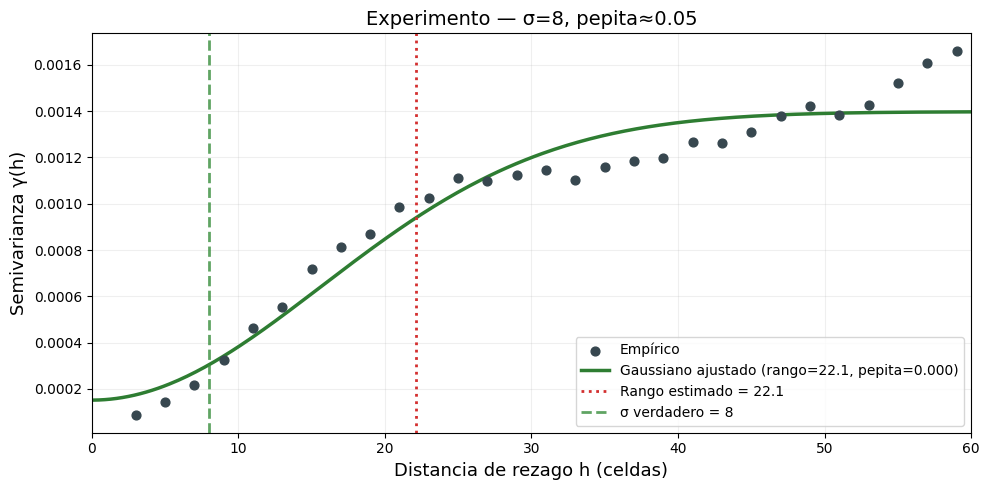

In [11]:
# ── Experimenta aquí ─────────────────────────────────────────
SIGMA_exp  = 8    # escala característica — prueba 5, 15, 25
NUGGET_exp = 0.05 # pepita — prueba 0.0, 0.1, 0.3
# ─────────────────────────────────────────────────────────────

np.random.seed(7)
land_e   = gaussian_filter(np.random.randn(n, n), sigma=SIGMA_exp)
xs_e     = np.random.randint(0, n, n_samples)
ys_e     = np.random.randint(0, n, n_samples)
val_e    = np.array([land_e[x, y] for x, y in zip(xs_e, ys_e)])
val_e   += np.random.randn(n_samples) * np.std(val_e) * np.sqrt(NUGGET_exp)  # simular pepita
coords_e = np.column_stack([xs_e, ys_e])
dists_e  = cdist(coords_e, coords_e)

gamma_e = []
for d in lag_centers:
    mask = np.triu((dists_e <= d) & (dists_e > d - 2), k=1)
    ii, jj = np.where(mask)
    if len(ii) < 10:
        gamma_e.append(np.nan); continue
    gamma_e.append(np.sum((val_e[ii] - val_e[jj])**2) / (2 * len(ii)))
gamma_e = np.array(gamma_e)

mv = ~np.isnan(gamma_e)
try:
    popt_e, _ = curve_fit(modelo_gaussiano, lag_centers[mv], gamma_e[mv],
                          p0=[0, np.var(val_e), 20],
                          bounds=([0, 0, 1], [np.var(val_e), np.var(val_e)*2, 80]),
                          maxfev=5000)
    label_fit = f"Gaussiano ajustado (rango={popt_e[2]:.1f}, pepita={popt_e[0]:.3f})"
except:
    popt_e, label_fit = None, "Ajuste fallido"

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(lag_centers[mv], gamma_e[mv], color='#37474F', s=40, label='Empírico', zorder=5)
if popt_e is not None:
    ax.plot(h_smooth, modelo_gaussiano(h_smooth, *popt_e),
            color='#2E7D32', linewidth=2.5, label=label_fit)
    ax.axvline(popt_e[2], color='#D32F2F', linestyle=':', linewidth=2,
               label=f'Rango estimado = {popt_e[2]:.1f}')
ax.axvline(SIGMA_exp, color='#388E3C', linestyle='--', linewidth=2, alpha=0.8,
           label=f'σ verdadero = {SIGMA_exp}')
ax.set_xlabel('Distancia de rezago h (celdas)', fontsize=13)
ax.set_ylabel('Semivarianza γ(h)', fontsize=13)
ax.set_title(f'Experimento — σ={SIGMA_exp}, pepita≈{NUGGET_exp}', fontsize=14)
ax.legend(fontsize=10); ax.grid(True, alpha=0.2); ax.set_xlim(0, 60)
plt.tight_layout(); plt.show()